# Pattern Graph

Generates the resource-type-level pattern graph from Neo4j using `ArchitecturalPatternAnalyzer.get_pattern_graph()`.

- Nodes = Azure resource types
- Edges = relationships between types, weighted by frequency
- Color = detected architectural pattern membership

**Prerequisites**: Neo4j running with scan data (`bolt://localhost:7687`)

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from src.architectural_pattern_analyzer import ArchitecturalPatternAnalyzer

In [2]:
import os
NEO4J_URI         = "bolt://localhost:7687"
NEO4J_USER        = "neo4j"
NEO4J_PASS        = os.getenv("NEO4J_PASSWORD")
TOP_N             = 40   # number of top nodes (by connection count) to render

# Azure tenant ID of the source scan.
# Filters out resources that belong to other tenants (e.g. foreign management groups).
# Set to None to disable filtering (not recommended when multiple tenants are in the graph).
SOURCE_TENANT_ID  = os.getenv("SOURCE_TENANT_ID", "<source-tenant-id>")

In [3]:
analyzer = ArchitecturalPatternAnalyzer(NEO4J_URI, NEO4J_USER, NEO4J_PASS,
                                        source_tenant_id=SOURCE_TENANT_ID)
analyzer.connect()

G = analyzer.get_pattern_graph()

print(f"Graph: {G.number_of_nodes()} resource types, {G.number_of_edges()} edges")

Graph: 132 resource types, 131 edges


In [ ]:
import sys
sys.path.insert(0, '..')
from src.architecture_based_replicator import ArchitecturePatternReplicator

# ── Predefined architectural patterns ────────────────────────────────────────
resource_type_counts = {node: G.nodes[node].get('count', 1) for node in G.nodes()}
pattern_matches = analyzer.detect_patterns(G, resource_type_counts)

print(f"Detected {len(pattern_matches)} predefined patterns:")
for name, match in sorted(pattern_matches.items(), key=lambda x: x[1]['completeness'], reverse=True):
    print(f"  {name}: {match['completeness']:.0f}%  ({len(match['matched_resources'])} resources)")

# ── Orphan-derived patterns from replicator ───────────────────────────────────
# Run analyze_source_tenant() once here; replicator is reused in later cells.
replicator = ArchitecturePatternReplicator(NEO4J_URI, NEO4J_USER, NEO4J_PASS,
                                           source_tenant_id=SOURCE_TENANT_ID)
analysis = replicator.analyze_source_tenant(use_configuration_coherence=True)

orphan_count = 0
for pname, instances in replicator.pattern_resources.items():
    if pname in pattern_matches:
        continue
    # collect simplified resource types present in the graph
    types_in_graph = sorted({
        r["type"] for inst in instances for r in inst
        if r["type"] in G.nodes()
    })
    if types_in_graph:
        pattern_matches[pname] = {
            "matched_resources": types_in_graph,
            "missing_resources": [],
            "connection_count": 0,
            "pattern_edges": [],
            "completeness": 100.0,
        }
        orphan_count += 1

print(f"\n+ {orphan_count} orphan-derived patterns -> {len(pattern_matches)} total")


In [5]:
# Keep only the TOP_N most-connected nodes
top_nodes = sorted(resource_type_counts.items(), key=lambda x: x[1], reverse=True)[:TOP_N]
top_node_names = [n for n, _ in top_nodes]
G_vis = G.subgraph(top_node_names).copy()

print(f"Visualising top {TOP_N} nodes: {G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges")

Visualising top 40 nodes: 40 nodes, 39 edges


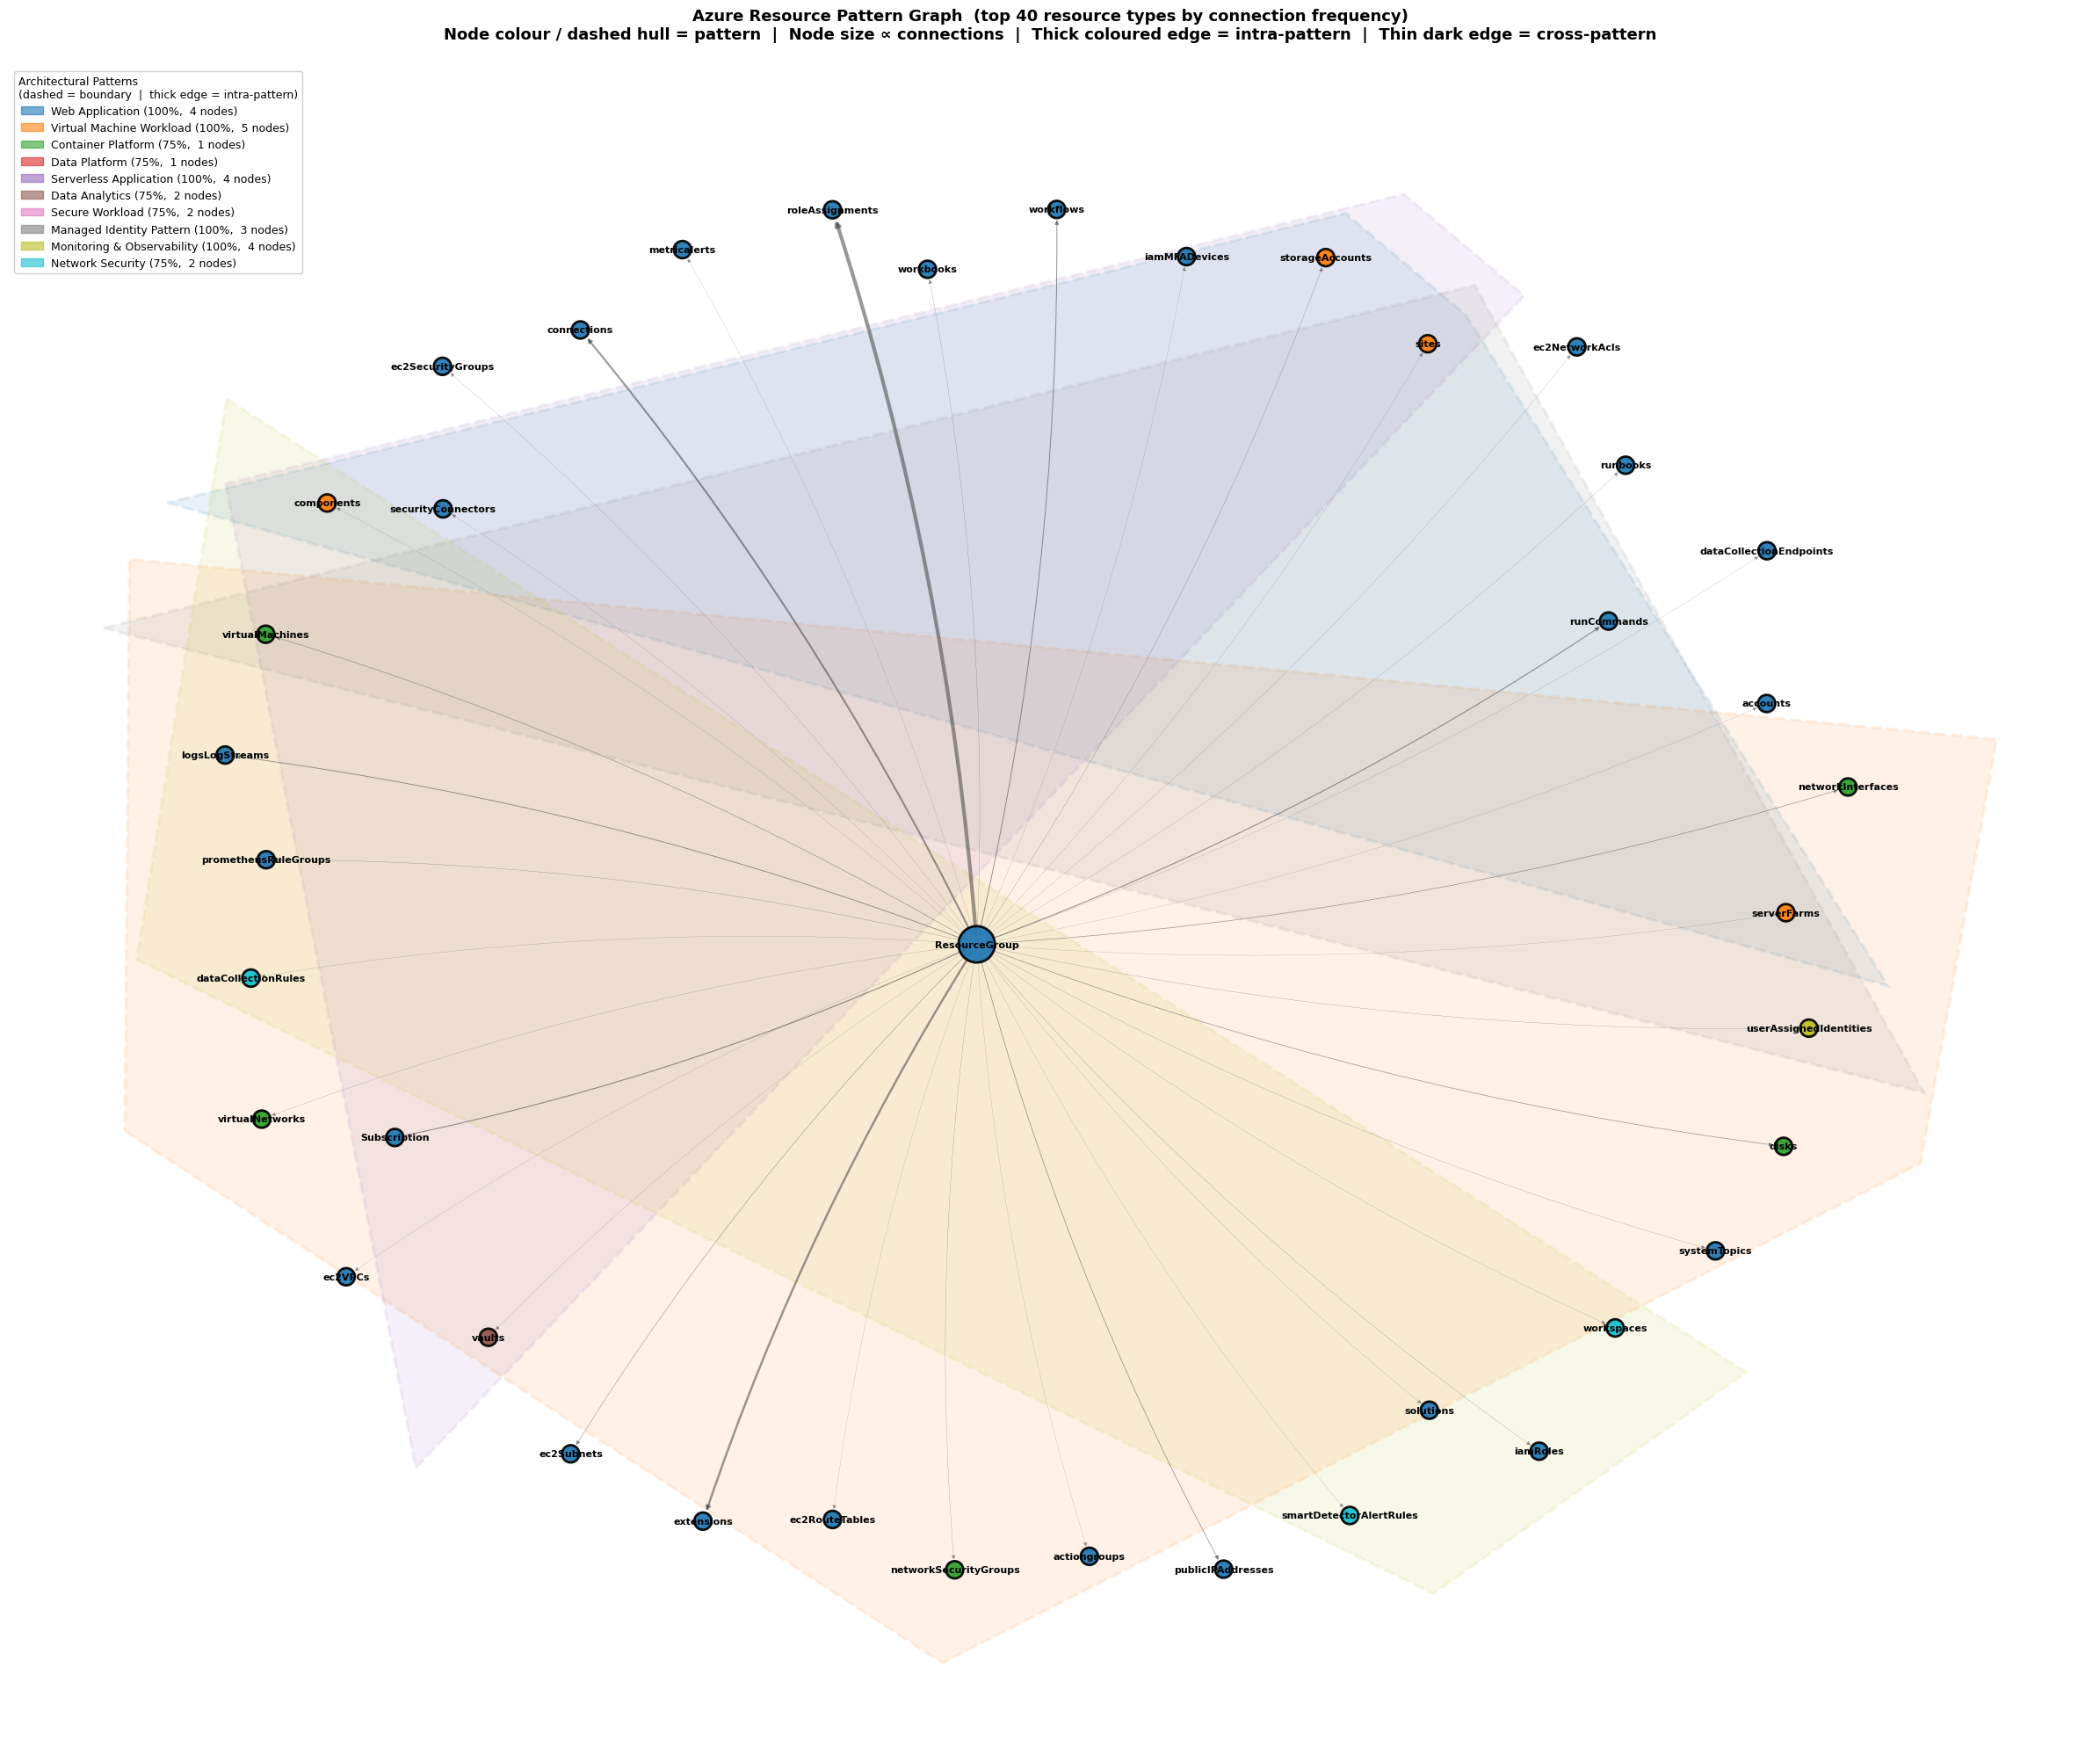

Saved → pattern_graph.png


In [6]:

import numpy as np
from matplotlib.patches import Patch, Polygon
from scipy.spatial import ConvexHull

cmap = plt.cm.tab10
pattern_names = list(pattern_matches.keys())

# ── per-node pattern membership ──────────────────────────────────────────────
node_pattern_map = {}   # node → list of pattern names it belongs to
node_best_pattern = {}  # node → index of highest-completeness pattern

for node in G_vis.nodes():
    matched = [
        (i, pname)
        for i, (pname, match) in enumerate(pattern_matches.items())
        if node in match['matched_resources']
    ]
    node_pattern_map[node] = [pname for _, pname in matched]
    if matched:
        best_i = max(matched, key=lambda t: pattern_matches[t[1]]['completeness'])[0]
        node_best_pattern[node] = best_i
    else:
        node_best_pattern[node] = -1

node_colors = [node_best_pattern[n] for n in G_vis.nodes()]
node_sizes  = [max(200, resource_type_counts.get(n, 1) / 3) for n in G_vis.nodes()]

pos = nx.spring_layout(G_vis, k=2.5, iterations=60, seed=42)

# ── split edges ───────────────────────────────────────────────────────────────
intra_edges, intra_widths, intra_colors = [], [], []
cross_edges, cross_widths = [], []

for u, v, data in G_vis.edges(data=True):
    freq = data.get('frequency', 1)
    width = max(0.4, freq / 60)
    shared = set(node_pattern_map.get(u, [])) & set(node_pattern_map.get(v, []))
    if shared:
        pname = next(iter(shared))
        pidx  = pattern_names.index(pname)
        intra_edges.append((u, v))
        intra_widths.append(width * 2.5)
        intra_colors.append(cmap(pidx / len(pattern_names)))
    else:
        cross_edges.append((u, v))
        cross_widths.append(width * 0.4)

# ── draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(24, 20))

# Layer 1 – convex hull shading per pattern
legend_patches = []
for pidx, (pname, match) in enumerate(pattern_matches.items()):
    members = [n for n in match['matched_resources'] if n in G_vis.nodes()]
    color   = cmap(pidx / len(pattern_names))
    if len(members) >= 3:
        try:
            pts     = np.array([[pos[n][0], pos[n][1]] for n in members])
            centre  = pts.mean(axis=0)
            pts_exp = centre + (pts - centre) * 1.18   # expand hull outward
            hull    = ConvexHull(pts_exp)
            polygon = Polygon(
                pts_exp[hull.vertices],
                facecolor=color, alpha=0.10,
                edgecolor=color, linewidth=2.5, linestyle='--',
                zorder=1,
            )
            ax.add_patch(polygon)
        except Exception:
            pass   # degenerate hull (collinear points)
    if members:
        legend_patches.append(
            Patch(facecolor=color, edgecolor=color, alpha=0.6,
                  label=f"{pname} ({match['completeness']:.0f}%,  {len(members)} nodes)")
        )

# Layer 2 – cross-pattern edges (dark grey, visible)
if cross_edges:
    nx.draw_networkx_edges(
        G_vis, pos, edgelist=cross_edges,
        width=cross_widths, alpha=0.55, edge_color='#444444',
        arrows=True, arrowsize=7,
        connectionstyle='arc3,rad=0.06', ax=ax,
    )

# Layer 3 – intra-pattern edges (coloured, thick)
for (u, v), w, ec in zip(intra_edges, intra_widths, intra_colors):
    nx.draw_networkx_edges(
        G_vis, pos, edgelist=[(u, v)],
        width=w, alpha=0.90, edge_color=[ec],
        arrows=True, arrowsize=12,
        connectionstyle='arc3,rad=0.10', ax=ax,
    )

# Layer 4 – nodes
nx.draw_networkx_nodes(
    G_vis, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=cmap, vmin=-1, vmax=len(pattern_names) - 1,
    alpha=0.93, edgecolors='black', linewidths=2.0,
    ax=ax,
)

# Layer 5 – labels
nx.draw_networkx_labels(G_vis, pos, font_size=8, font_weight='bold', ax=ax)

# Legend
ax.legend(
    handles=legend_patches,
    loc='upper left', fontsize=9, framealpha=0.92,
    title='Architectural Patterns\n(dashed = boundary  |  thick edge = intra-pattern)',
    title_fontsize=9,
)

ax.set_title(
    f'Azure Resource Pattern Graph  (top {TOP_N} resource types by connection frequency)\n'
    'Node colour / dashed hull = pattern  |  Node size ∝ connections  '
    '|  Thick coloured edge = intra-pattern  |  Thin dark edge = cross-pattern',
    fontsize=13, fontweight='bold', pad=22,
)
ax.axis('off')
plt.tight_layout()
plt.savefig('pattern_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → pattern_graph.png")


In [7]:
# Top 15 resource types by connection count
import pandas as pd

df = pd.DataFrame(top_nodes[:15], columns=['resource_type', 'connection_count'])
print("Top 15 resource types by connection count:")
display(df)

Top 15 resource types by connection count:


,resource_type,connection_count
0,ResourceGroup,2660
1,roleAssignments,450
2,extensions,266
3,connections,227
4,Subscription,127
5,runCommands,119
6,workflows,108
7,logsLogStreams,100
8,publicIPAddresses,81
9,disks,74


## Replication by Resource Count

Add architecture instances—proportionally across patterns—until a target total resource count is reached.


In [ ]:
TARGET_RESOURCE_COUNT = 300  # change me

# replicator and analysis already created in the detect-patterns cell above
print(f"Source tenant: {analysis['detected_patterns']} patterns, "
      f"{analysis['total_pattern_resources']} total pattern resources")

selected, history, meta = replicator.generate_replication_plan_by_resource_count(
    target_resource_count=TARGET_RESOURCE_COUNT,
)

print(f"\nPlan: {meta['total_instances']} instances -> {meta['actual_resource_count']} resources "
      f"(target was {TARGET_RESOURCE_COUNT})")
print("\nInstances per pattern:")
for pattern, count in sorted(meta['instance_counts_by_pattern'].items(), key=lambda x: -x[1]):
    if count:
        avg = sum(len(inst) for pn, inst in selected if pn == pattern) / count
        print(f"  {pattern:<35} {count:>3} instances  (~{avg:.1f} resources each)")


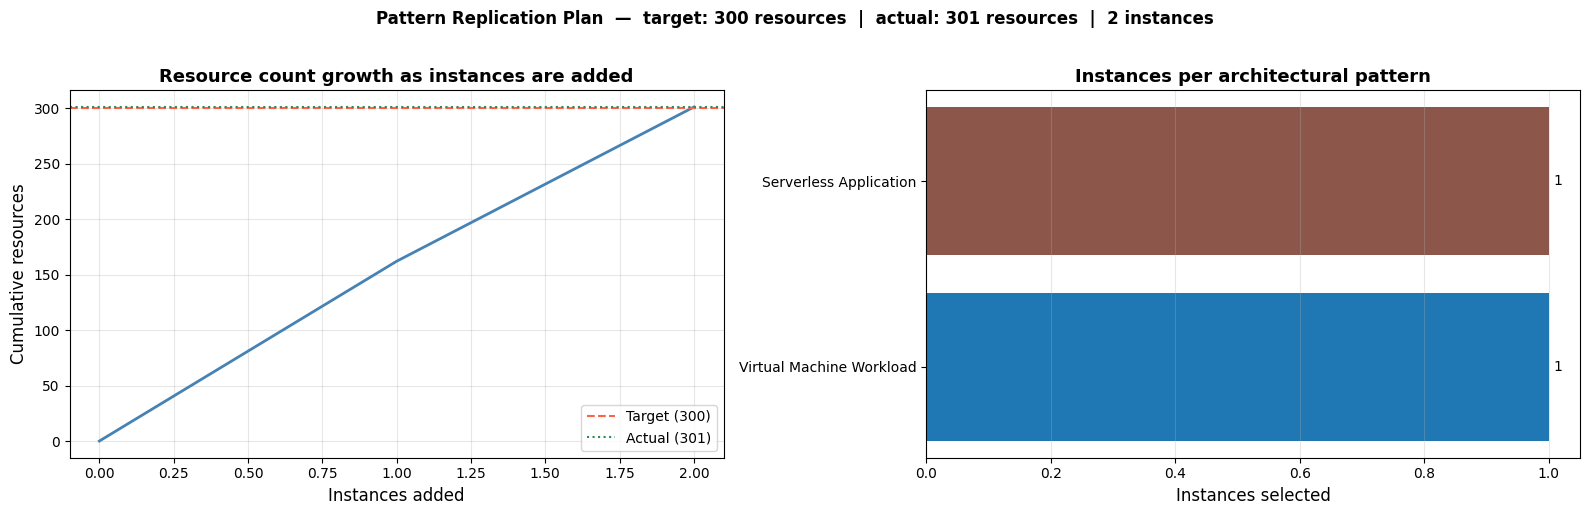

Saved → replication_by_resource_count.png


In [ ]:

# Resource accumulation curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: cumulative resource count growth
ax1.plot(range(len(history)), history, linewidth=2, color='steelblue')
ax1.axhline(TARGET_RESOURCE_COUNT, color='tomato', linestyle='--', linewidth=1.5,
            label=f'Target ({TARGET_RESOURCE_COUNT})')
ax1.axhline(meta['actual_resource_count'], color='seagreen', linestyle=':', linewidth=1.5,
            label=f"Actual ({meta['actual_resource_count']})")
ax1.set_xlabel('Instances added', fontsize=12)
ax1.set_ylabel('Cumulative resources', fontsize=12)
ax1.set_title('Resource count growth as instances are added', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: instance count per pattern (bar chart)
pattern_counts = {k: v for k, v in meta['instance_counts_by_pattern'].items() if v > 0}
bars = ax2.barh(list(pattern_counts.keys()), list(pattern_counts.values()),
                color=[cmap(i / max(len(pattern_counts), 1)) for i in range(len(pattern_counts))])
ax2.set_xlabel('Instances selected', fontsize=12)
ax2.set_title('Instances per architectural pattern', fontsize=13, fontweight='bold')
ax2.bar_label(bars, padding=3, fontsize=10)
ax2.grid(True, axis='x', alpha=0.3)

plt.suptitle(
    f'Pattern Replication Plan  —  target: {TARGET_RESOURCE_COUNT} resources  '
    f'|  actual: {meta["actual_resource_count"]} resources  '
    f'|  {meta["total_instances"]} instances',
    fontsize=12, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig('replication_by_resource_count.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → replication_by_resource_count.png")


In [ ]:

# ── Generate a 500-resource replication plan ──────────────────────────────────
# replicator already has pattern_resources cached from analyze_source_tenant() above.
selected_500, history_500, meta_500 = replicator.generate_replication_plan_by_resource_count(
    target_resource_count=500,
)

print(f"Plan: {meta_500['total_instances']} instances → {meta_500['actual_resource_count']} resources")
print(f"\nInstances per pattern:")
for pname, count in sorted(meta_500['instance_counts_by_pattern'].items(), key=lambda x: -x[1]):
    if count:
        resources_in_pattern = sum(len(inst) for pn, inst in selected_500 if pn == pname)
        print(f"  {pname:<35}  {count:>3} instances   {resources_in_pattern:>5} resources")


Plan: 29 instances → 631 resources

Instances per pattern:
  Web Application                        3 instances     138 resources
  Virtual Machine Workload               3 instances      33 resources
  Serverless Application                 3 instances       3 resources
  Managed Identity Pattern               3 instances      23 resources
  Container Platform                     2 instances       7 resources
  Data Analytics                         2 instances       2 resources
  Secure Workload                        2 instances      15 resources
  Monitoring & Observability             2 instances       2 resources
  Network Security                       2 instances      15 resources
  Data Platform                          1 instances       1 resources
  Supported metrics - Microsoft.EventGrid/systemTopics    1 instances       1 resources
  Migrate to Azure role-based access control    1 instances      10 resources
  Create an Azure storage account        1 instances       3 reso

Resource graph: 566 nodes, 77810 edges


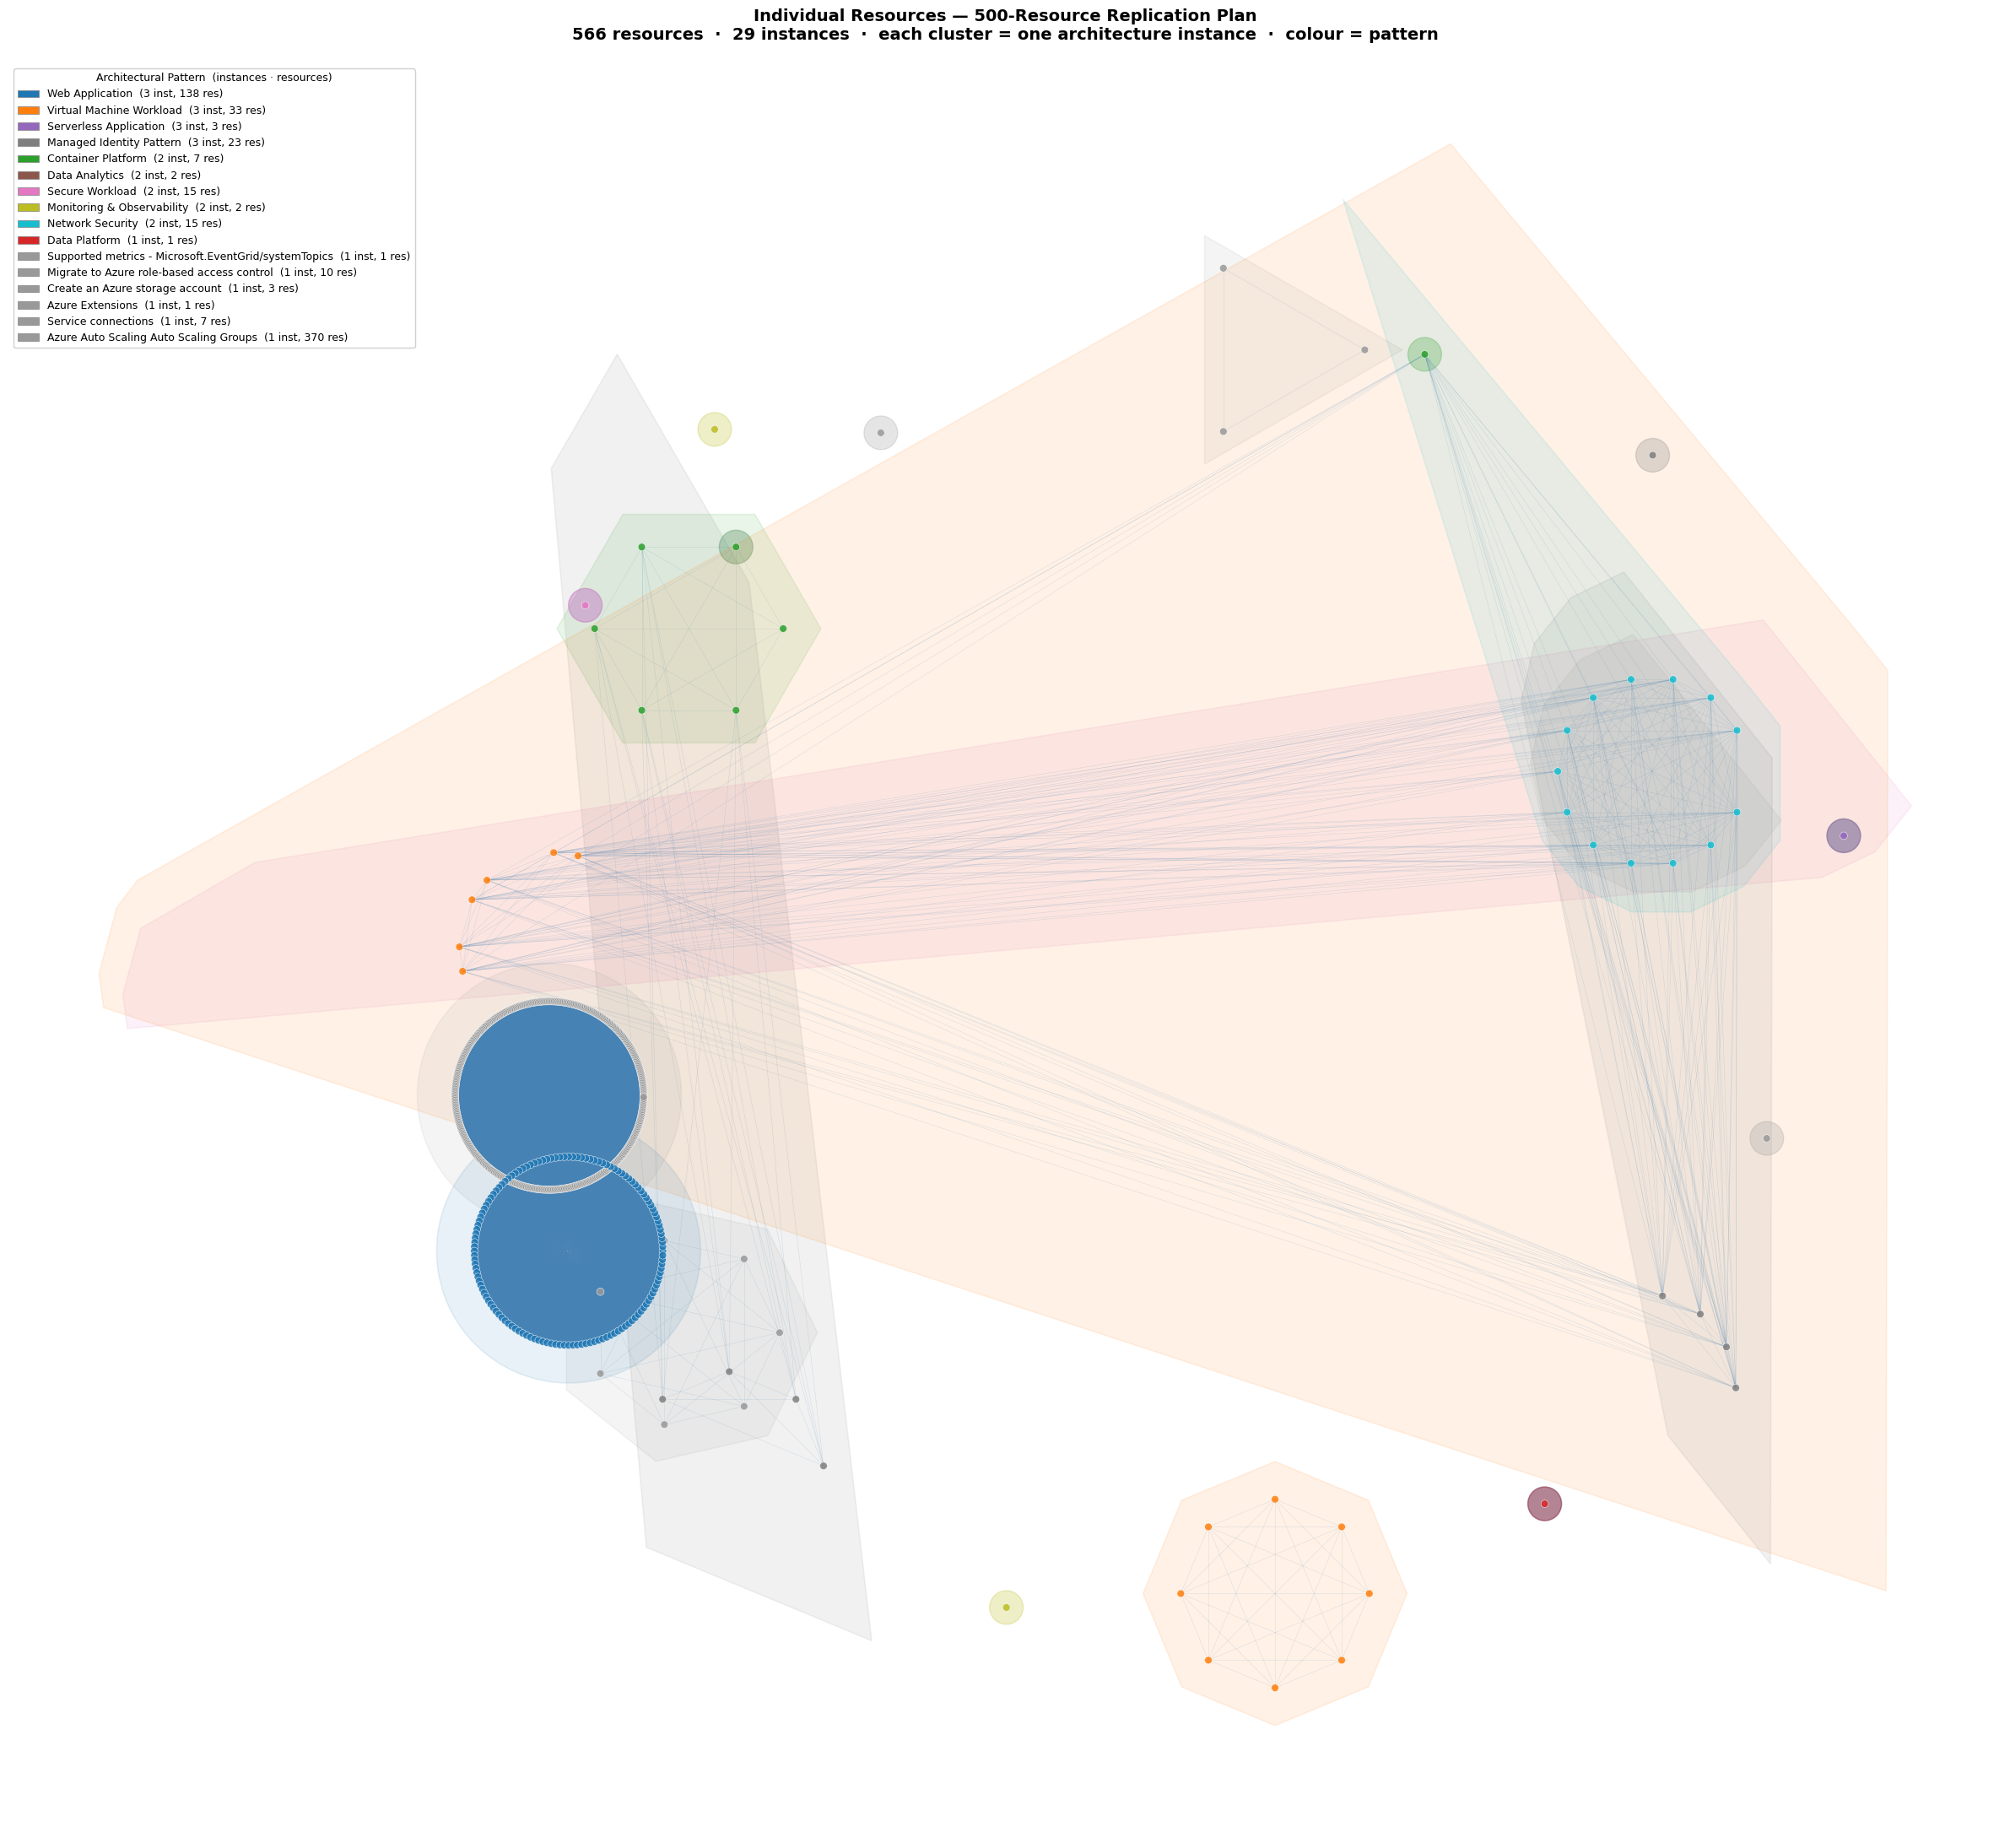

Saved → resource_instance_graph_500.png


In [ ]:

# ── Individual-resource graph for the 500-resource plan ──────────────────────
#
# Nodes  = individual resources (Azure resource IDs)
# Edges  = resources that share an architecture instance (co-located in same RG)
# Layout = two-level:
#            1. instance centres placed with spring layout  (instances as meta-nodes)
#            2. resources within an instance arranged in a small circle around centre
# Colour = architectural pattern the instance belongs to
# Hull   = convex hull outline around each instance

import itertools
from matplotlib.patches import Patch, Polygon, FancyArrowPatch
from scipy.spatial import ConvexHull

# ── build graph ───────────────────────────────────────────────────────────────
G_res = nx.Graph()
for instance_idx, (pname, inst) in enumerate(selected_500):
    for resource in inst:
        rid = resource["id"]
        rtype = resource.get("type", "unknown")
        G_res.add_node(rid, rtype=rtype, pattern=pname, instance=instance_idx)
    # connect every pair within an instance
    for r1, r2 in itertools.combinations(inst, 2):
        G_res.add_edge(r1["id"], r2["id"])

print(f"Resource graph: {G_res.number_of_nodes()} nodes, {G_res.number_of_edges()} edges")

# ── two-level layout ──────────────────────────────────────────────────────────
n_instances = len(selected_500)

# meta-graph: one node per instance, no edges (pure spring layout for spacing)
meta = nx.Graph()
meta.add_nodes_from(range(n_instances))
meta_pos = nx.spring_layout(meta, k=6.0, seed=42)

INSTANCE_RADIUS = 0.14   # spread resources within an instance

pos = {}
for i, (pname, inst) in enumerate(selected_500):
    cx, cy = meta_pos[i]
    n = len(inst)
    for j, resource in enumerate(inst):
        if n == 1:
            pos[resource["id"]] = (cx, cy)
        else:
            angle = 2 * np.pi * j / n
            pos[resource["id"]] = (cx + INSTANCE_RADIUS * np.cos(angle),
                                   cy + INSTANCE_RADIUS * np.sin(angle))

# ── colours ───────────────────────────────────────────────────────────────────
cmap_res = plt.cm.tab10
all_pattern_names = list(pattern_matches.keys())   # from earlier cells

def pattern_color(pname):
    try:
        idx = all_pattern_names.index(pname)
        return cmap_res(idx / len(all_pattern_names))
    except ValueError:
        return (0.6, 0.6, 0.6, 1.0)   # grey for orphaned / unknown

node_colors = [pattern_color(G_res.nodes[n]["pattern"]) for n in G_res.nodes()]

# ── draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(26, 22))
ax.set_aspect("equal")

# Layer 1 – instance hulls (one per instance)
for i, (pname, inst) in enumerate(selected_500):
    color = pattern_color(pname)
    pts   = np.array([pos[r["id"]] for r in inst])

    if len(inst) == 1:
        # single node → small filled circle
        circle = plt.Circle(pts[0], radius=0.025, color=color, alpha=0.25, zorder=1)
        ax.add_patch(circle)

    elif len(inst) == 2:
        # two nodes → thick segment behind the edge
        ax.plot(pts[:, 0], pts[:, 1], linewidth=8, color=color, alpha=0.15,
                solid_capstyle="round", zorder=1)

    else:
        try:
            centre  = pts.mean(axis=0)
            pts_exp = centre + (pts - centre) * 1.4
            hull    = ConvexHull(pts_exp)
            polygon = Polygon(
                pts_exp[hull.vertices],
                facecolor=color, alpha=0.10,
                edgecolor=color, linewidth=1.2, linestyle="-",
                zorder=1,
            )
            ax.add_patch(polygon)
        except Exception:
            pass   # collinear — skip hull

# Layer 2 – intra-instance edges
nx.draw_networkx_edges(
    G_res, pos,
    width=0.4, alpha=0.18, edge_color="steelblue",
    ax=ax,
)

# Layer 3 – nodes  (small, coloured by pattern)
nx.draw_networkx_nodes(
    G_res, pos,
    node_size=40,
    node_color=node_colors,
    alpha=0.85,
    linewidths=0.4,
    edgecolors="white",
    ax=ax,
)

# ── legend ────────────────────────────────────────────────────────────────────
legend_handles = []
for pname, count in sorted(meta_500["instance_counts_by_pattern"].items(), key=lambda x: -x[1]):
    if count == 0:
        continue
    n_res = sum(len(inst) for pn, inst in selected_500 if pn == pname)
    legend_handles.append(
        Patch(facecolor=pattern_color(pname), edgecolor="grey", linewidth=0.5,
              label=f"{pname}  ({count} inst, {n_res} res)")
    )

ax.legend(
    handles=legend_handles,
    loc="upper left", fontsize=9, framealpha=0.92,
    title="Architectural Pattern  (instances · resources)",
    title_fontsize=9,
)

ax.set_title(
    f"Individual Resources — 500-Resource Replication Plan\n"
    f"{G_res.number_of_nodes()} resources  ·  {meta_500['total_instances']} instances  "
    f"·  each cluster = one architecture instance  ·  colour = pattern",
    fontsize=14, fontweight="bold", pad=20,
)
ax.axis("off")
plt.tight_layout()
plt.savefig("resource_instance_graph_500.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → resource_instance_graph_500.png")


## Architecture Instance Co-occurrence Graph

Builds two graphs that show how architectural instances relate to each other through **shared ResourceGroups**:

- **Left — Instance graph**: each node is one specific instance. An edge means both instances have at least one resource in the same Azure ResourceGroup. Hulls group instances of the same pattern.
- **Right — Pattern graph**: aggregated view. Nodes = patterns, edges = how frequently instances of those two patterns share a ResourceGroup. This is the architecture-level equivalent of the resource-type pattern graph.

Instance graph : 29 nodes, 47 edges
Pattern graph  : 16 nodes,  32 edges

Pattern-level connections:
  Virtual Machine Workload  ↔  Managed Identity Pattern   (3 instance pair(s), 3 shared RG(s))
  Virtual Machine Workload  ↔  Network Security   (3 instance pair(s), 3 shared RG(s))
  Virtual Machine Workload  ↔  Container Platform   (3 instance pair(s), 3 shared RG(s))
  Virtual Machine Workload  ↔  Secure Workload   (2 instance pair(s), 2 shared RG(s))
  Virtual Machine Workload  ↔  Migrate to Azure role-based access control   (2 instance pair(s), 2 shared RG(s))
  Virtual Machine Workload  ↔  Azure Extensions   (2 instance pair(s), 2 shared RG(s))
  Serverless Application  ↔  Web Application   (2 instance pair(s), 2 shared RG(s))
  Serverless Application  ↔  Data Analytics   (2 instance pair(s), 2 shared RG(s))
  Managed Identity Pattern  ↔  Network Security   (2 instance pair(s), 2 shared RG(s))
  Managed Identity Pattern  ↔  Container Platform   (2 instance pair(s), 2 shared RG(s))

/var/folders/zb/gt9ycphn2pg1jm4rjmkpy8br0000gn/T/ipykernel_72174/3392804581.py:63: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/var/folders/zb/gt9ycphn2pg1jm4rjmkpy8br0000gn/T/ipykernel_72174/3392804581.py:105: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


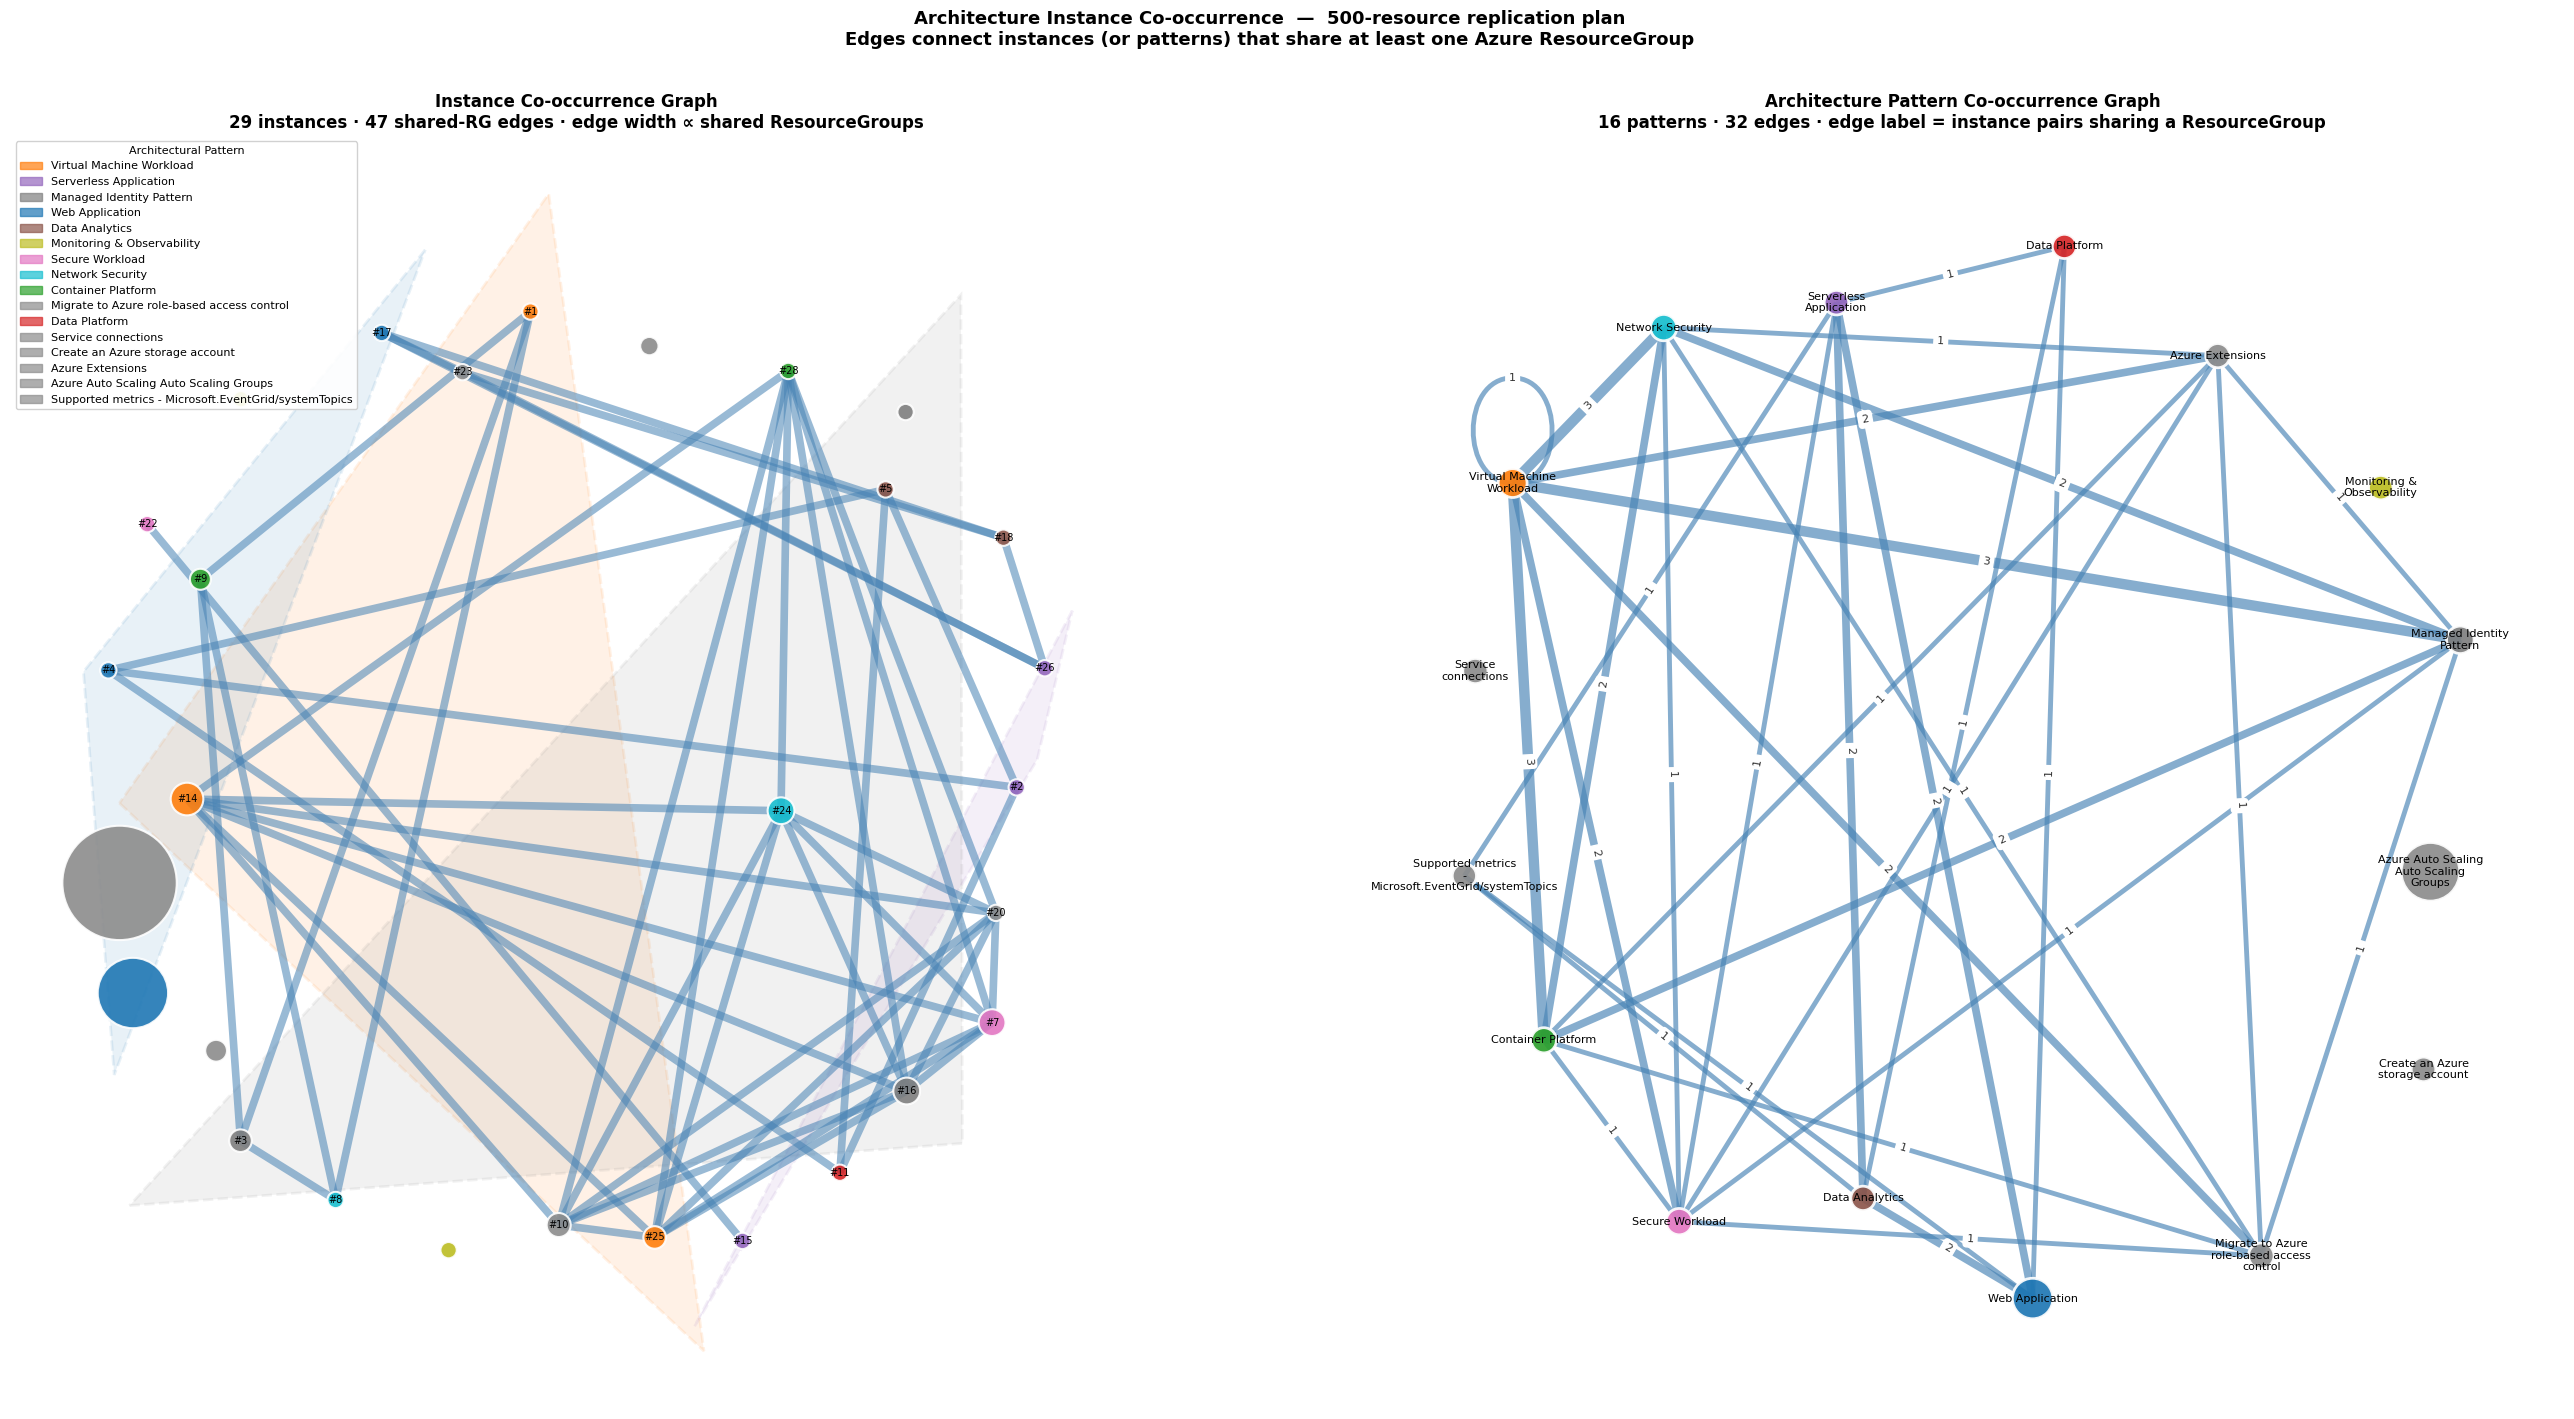

Saved → architecture_cooccurrence_graph.png


In [ ]:

import itertools
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch, Polygon
from scipy.spatial import ConvexHull

# ── build co-occurrence graphs ────────────────────────────────────────────────
G_inst, G_pat = replicator.build_instance_cooccurrence_graph(selected_500)

print(f"Instance graph : {G_inst.number_of_nodes()} nodes, {G_inst.number_of_edges()} edges")
print(f"Pattern graph  : {G_pat.number_of_nodes()} nodes,  {G_pat.number_of_edges()} edges")
print(f"\nPattern-level connections:")
for u, v, d in sorted(G_pat.edges(data=True), key=lambda x: -x[2]['instance_pairs']):
    print(f"  {u}  ↔  {v}   ({d['instance_pairs']} instance pair(s), {d['weight']} shared RG(s))")

# ── shared colour map keyed by pattern name ───────────────────────────────────
all_pattern_names = list(pattern_matches.keys())
def pat_color(pname):
    try:
        return plt.cm.tab10(all_pattern_names.index(pname) / len(all_pattern_names))
    except ValueError:
        return (0.55, 0.55, 0.55, 1.0)

# ── layout ────────────────────────────────────────────────────────────────────
inst_pos  = nx.spring_layout(G_inst, weight="shared_rgs", k=3.0, seed=42)
pat_pos   = nx.spring_layout(G_pat,  weight="weight",     k=4.0, seed=7)

fig, (ax_inst, ax_pat) = plt.subplots(1, 2, figsize=(28, 14))

# ════════════════════════════════════════════════════════════════════════
# LEFT — instance graph
# ════════════════════════════════════════════════════════════════════════
ax_inst.set_aspect("equal")

# Convex hull per pattern
pattern_to_indices = defaultdict(list)
for i, (pname, _) in enumerate(selected_500):
    pattern_to_indices[pname].append(i)

legend_patches = []
for pname, indices in pattern_to_indices.items():
    color = pat_color(pname)
    pts   = np.array([inst_pos[i] for i in indices])
    if len(indices) >= 3:
        try:
            centre  = pts.mean(axis=0)
            pts_exp = centre + (pts - centre) * 1.25
            hull    = ConvexHull(pts_exp)
            ax_inst.add_patch(Polygon(
                pts_exp[hull.vertices],
                facecolor=color, alpha=0.10,
                edgecolor=color, linewidth=2, linestyle="--", zorder=1,
            ))
        except Exception:
            pass
    legend_patches.append(Patch(facecolor=color, edgecolor=color, alpha=0.7, label=pname))

# Edges
edge_weights = [G_inst[u][v]["shared_rgs"] for u, v in G_inst.edges()]
max_w = max(edge_weights, default=1)
nx.draw_networkx_edges(
    G_inst, inst_pos,
    width=[1.5 + 4 * w / max_w for w in edge_weights],
    alpha=0.55, edge_color="steelblue",
    connectionstyle="arc3,rad=0.08", ax=ax_inst,
)

# Nodes
node_colors = [pat_color(G_inst.nodes[i]["pattern"]) for i in G_inst.nodes()]
node_sizes  = [120 + G_inst.nodes[i]["size"] * 18 for i in G_inst.nodes()]
nx.draw_networkx_nodes(
    G_inst, inst_pos,
    node_color=node_colors, node_size=node_sizes,
    alpha=0.90, edgecolors="white", linewidths=1.5, ax=ax_inst,
)

# Labels — only for connected nodes to avoid clutter
labels = {
    i: f"#{i+1}" for i in G_inst.nodes() if G_inst.degree(i) > 0
}
nx.draw_networkx_labels(G_inst, inst_pos, labels=labels, font_size=7, ax=ax_inst)

ax_inst.legend(handles=legend_patches, loc="upper left", fontsize=8,
               title="Architectural Pattern", title_fontsize=8, framealpha=0.9)
ax_inst.set_title(
    f"Instance Co-occurrence Graph\n"
    f"{G_inst.number_of_nodes()} instances · {G_inst.number_of_edges()} shared-RG edges · "
    f"edge width ∝ shared ResourceGroups",
    fontsize=12, fontweight="bold",
)
ax_inst.axis("off")

# ════════════════════════════════════════════════════════════════════════
# RIGHT — pattern graph
# ════════════════════════════════════════════════════════════════════════
ax_pat.set_aspect("equal")

pat_colors  = [pat_color(n) for n in G_pat.nodes()]
pat_sizes   = [300 + G_pat.nodes[n]["resource_count"] * 4 for n in G_pat.nodes()]
pat_weights = [G_pat[u][v]["instance_pairs"] for u, v in G_pat.edges()]
max_pw      = max(pat_weights, default=1)

nx.draw_networkx_edges(
    G_pat, pat_pos,
    width=[1.5 + 6 * w / max_pw for w in pat_weights],
    alpha=0.65, edge_color="steelblue",
    connectionstyle="arc3,rad=0.10", ax=ax_pat,
)

# Edge labels: number of instance pairs
edge_labels = {(u, v): d["instance_pairs"] for u, v, d in G_pat.edges(data=True)}
nx.draw_networkx_edge_labels(
    G_pat, pat_pos, edge_labels=edge_labels,
    font_size=8, font_color="#333", ax=ax_pat,
)

nx.draw_networkx_nodes(
    G_pat, pat_pos,
    node_color=pat_colors, node_size=pat_sizes,
    alpha=0.92, edgecolors="white", linewidths=2, ax=ax_pat,
)

# Wrap long pattern names for readability
def wrap(s, width=18):
    words, line, lines = s.split(), "", []
    for w in words:
        if len(line) + len(w) + 1 > width:
            lines.append(line); line = w
        else:
            line = (line + " " + w).strip()
    if line: lines.append(line)
    return "\n".join(lines)

pat_labels = {n: wrap(n) for n in G_pat.nodes()}
nx.draw_networkx_labels(G_pat, pat_pos, labels=pat_labels, font_size=8, ax=ax_pat)

ax_pat.set_title(
    f"Architecture Pattern Co-occurrence Graph\n"
    f"{G_pat.number_of_nodes()} patterns · {G_pat.number_of_edges()} edges · "
    f"edge label = instance pairs sharing a ResourceGroup",
    fontsize=12, fontweight="bold",
)
ax_pat.axis("off")

plt.suptitle(
    "Architecture Instance Co-occurrence  —  500-resource replication plan\n"
    "Edges connect instances (or patterns) that share at least one Azure ResourceGroup",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("architecture_cooccurrence_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → architecture_cooccurrence_graph.png")


## Neo4j Browser — Replication Plan Visualisation

Tags the selected resources with a temporary `:ReplicationPlan` label in Neo4j,
then provides a one-click link to explore the full graph interactively in Neo4j Browser.

In [ ]:

# ── Tag plan resources in Neo4j, then open Browser at the existing localhost:7474 ──
from urllib.parse import quote
from IPython.display import HTML, display
from neo4j import GraphDatabase as _GDB

PLAN       = selected_500   # swap to `selected` for the 300-resource plan
TEMP_LABEL = "ReplicationPlan"

selected_ids = [r["id"] for _, inst in PLAN for r in inst]

_driver = _GDB.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
with _driver.session() as _s:
    _s.run(f"MATCH (r:`{TEMP_LABEL}`) REMOVE r:`{TEMP_LABEL}`")   # clear stale tags
    result = _s.run(
        f"MATCH (r:Resource:Original) WHERE r.id IN $ids SET r:`{TEMP_LABEL}` RETURN count(r) AS n",
        ids=selected_ids,
    )
    tagged = result.single()["n"]
_driver.close()

print(f"Tagged {tagged} / {len(selected_ids)} nodes with :{TEMP_LABEL}")
if tagged == 0:
    raise RuntimeError(f"No nodes matched — sample IDs from plan:\n{selected_ids[:3]}")

cypher = f"MATCH (r:`{TEMP_LABEL}`) OPTIONAL MATCH (r)-[rel]->(r2:`{TEMP_LABEL}`) RETURN r, rel, r2"
url    = f"http://localhost:7474/browser/?cmd=edit&arg={quote(cypher)}"

display(HTML(f"""
<div style="padding:14px 18px; background:#f0f7ff;
            border-left:4px solid #1976d2; border-radius:6px; font-family:sans-serif;">
  <b style="font-size:15px;">{tagged} resources tagged &rarr; ready in Neo4j Browser</b><br><br>
  <a href="{url}" target="_blank" style="font-size:15px; color:#1565c0; font-weight:bold;">
    &#128279;&nbsp; Open Neo4j Browser (localhost:7474) &rarr;
  </a>
  <br><br>
  <details>
    <summary style="cursor:pointer; color:#555; font-size:12px;">Show Cypher</summary>
    <pre style="background:#fff; border:1px solid #ddd; padding:8px; margin-top:6px; font-size:11px;">{cypher}</pre>
  </details>
  <br>
  <span style="font-size:11px; color:#888;">
    In the Browser: press <b>Ctrl+Enter</b> to run &nbsp;|&nbsp;
    switch to <b>Graph</b> view (top-right of result panel) &nbsp;|&nbsp;
    label is cleaned up by the cleanup cell below
  </span>
</div>
"""))


Tagged 566 / 631 nodes with :ReplicationPlan


In [ ]:
from neo4j import GraphDatabase

analyzer.close()

# Remove the temporary ReplicationPlan label
_d = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
with _d.session() as _s:
    r = _s.run("MATCH (r:ReplicationPlan) REMOVE r:ReplicationPlan RETURN count(r) AS n").single()
    if r and r["n"]:
        print(f"Removed :ReplicationPlan label from {r['n']} nodes")
_d.close()

Removed :ReplicationPlan label from 566 nodes
